# Lecture 21

Lets walk through building a very simple Deep Neural Network for our Tabular datasets.

First, lets take a quick walk-through of [Keras](https://keras.io).


## Tabular Data

I've copied all of my functions that loaded and visualized the data from from my previous notbook into a module, so that I can use them here:

In [1]:
!ls train/334_361110

attribute_names.json       data_train.parquet
categorical_indicator.json target_train.parquet
data_test.parquet


In [2]:
from dataloader import *

Processing: 335_361288
Processing: 334_361283
Processing: 334_361282
Processing: 335_361289
Processing: 334_361285
Processing: 335_361287
Processing: 336_361072
Processing: 336_361086
Processing: 337_361274
Processing: 336_361081
Processing: 337_361273
Processing: 336_361088
Processing: 337_361070
Processing: 335_361102
Processing: 336_361074
Processing: 336_361080
Processing: 336_361279
Processing: 336_361087
Processing: 336_361073
Processing: 337_361275
Processing: 335_361103
Processing: 335_361104
Processing: 337_361065
Processing: 337_361062
Processing: 334_361113
Processing: 337_361055
Processing: 337_361063
Processing: 335_361097
Processing: 335_361293
Processing: 335_361294
Processing: 335_361099
Processing: 335_361098
Processing: 335_361292
Processing: 335_361096
Processing: 334_361286
Processing: 335_361101
Processing: 336_361082
Processing: 336_361076
Processing: 336_361085
Processing: 337_361277
Processing: 336_361281
Processing: 336_361078
Processing: 337_361278
Processing:

In [3]:
import glob 
import pandas as pd
PATH = "./"
target_files = glob.glob(PATH+"train/*/target_train.parquet")

print(target_files)

df = pd.read_parquet(target_files[7])

['./train/335_361288/target_train.parquet', './train/334_361283/target_train.parquet', './train/334_361282/target_train.parquet', './train/335_361289/target_train.parquet', './train/334_361285/target_train.parquet', './train/335_361287/target_train.parquet', './train/336_361072/target_train.parquet', './train/336_361086/target_train.parquet', './train/337_361274/target_train.parquet', './train/336_361081/target_train.parquet', './train/337_361273/target_train.parquet', './train/336_361088/target_train.parquet', './train/337_361070/target_train.parquet', './train/335_361102/target_train.parquet', './train/336_361074/target_train.parquet', './train/336_361080/target_train.parquet', './train/336_361279/target_train.parquet', './train/336_361087/target_train.parquet', './train/336_361073/target_train.parquet', './train/337_361275/target_train.parquet', './train/335_361103/target_train.parquet', './train/335_361104/target_train.parquet', './train/337_361065/target_train.parquet', './train/3

In [4]:
d1=load_dataset(binary_classification_datasets[7])

Number of catogory 0: 4026
Number of catogory 1: 3999
Found 10 features. Creating grid of 4 by 3
fLength: KS Distribution Similarity Test: 0.23486721158680132
fWidth: KS Distribution Similarity Test: 0.21895041569632348
fSize: KS Distribution Similarity Test: 0.12879207134123322
fConc: KS Distribution Similarity Test: 0.07822205178716438
fConc1: KS Distribution Similarity Test: 0.07516092883131364
fAsym: KS Distribution Similarity Test: 0.16385560622644485
fM3Long: KS Distribution Similarity Test: 0.1969147279368277
fM3Trans: KS Distribution Similarity Test: 0.1055329033450613
fAlpha: KS Distribution Similarity Test: 0.45540930687217257
fDist: KS Distribution Similarity Test: 0.07662981319100266


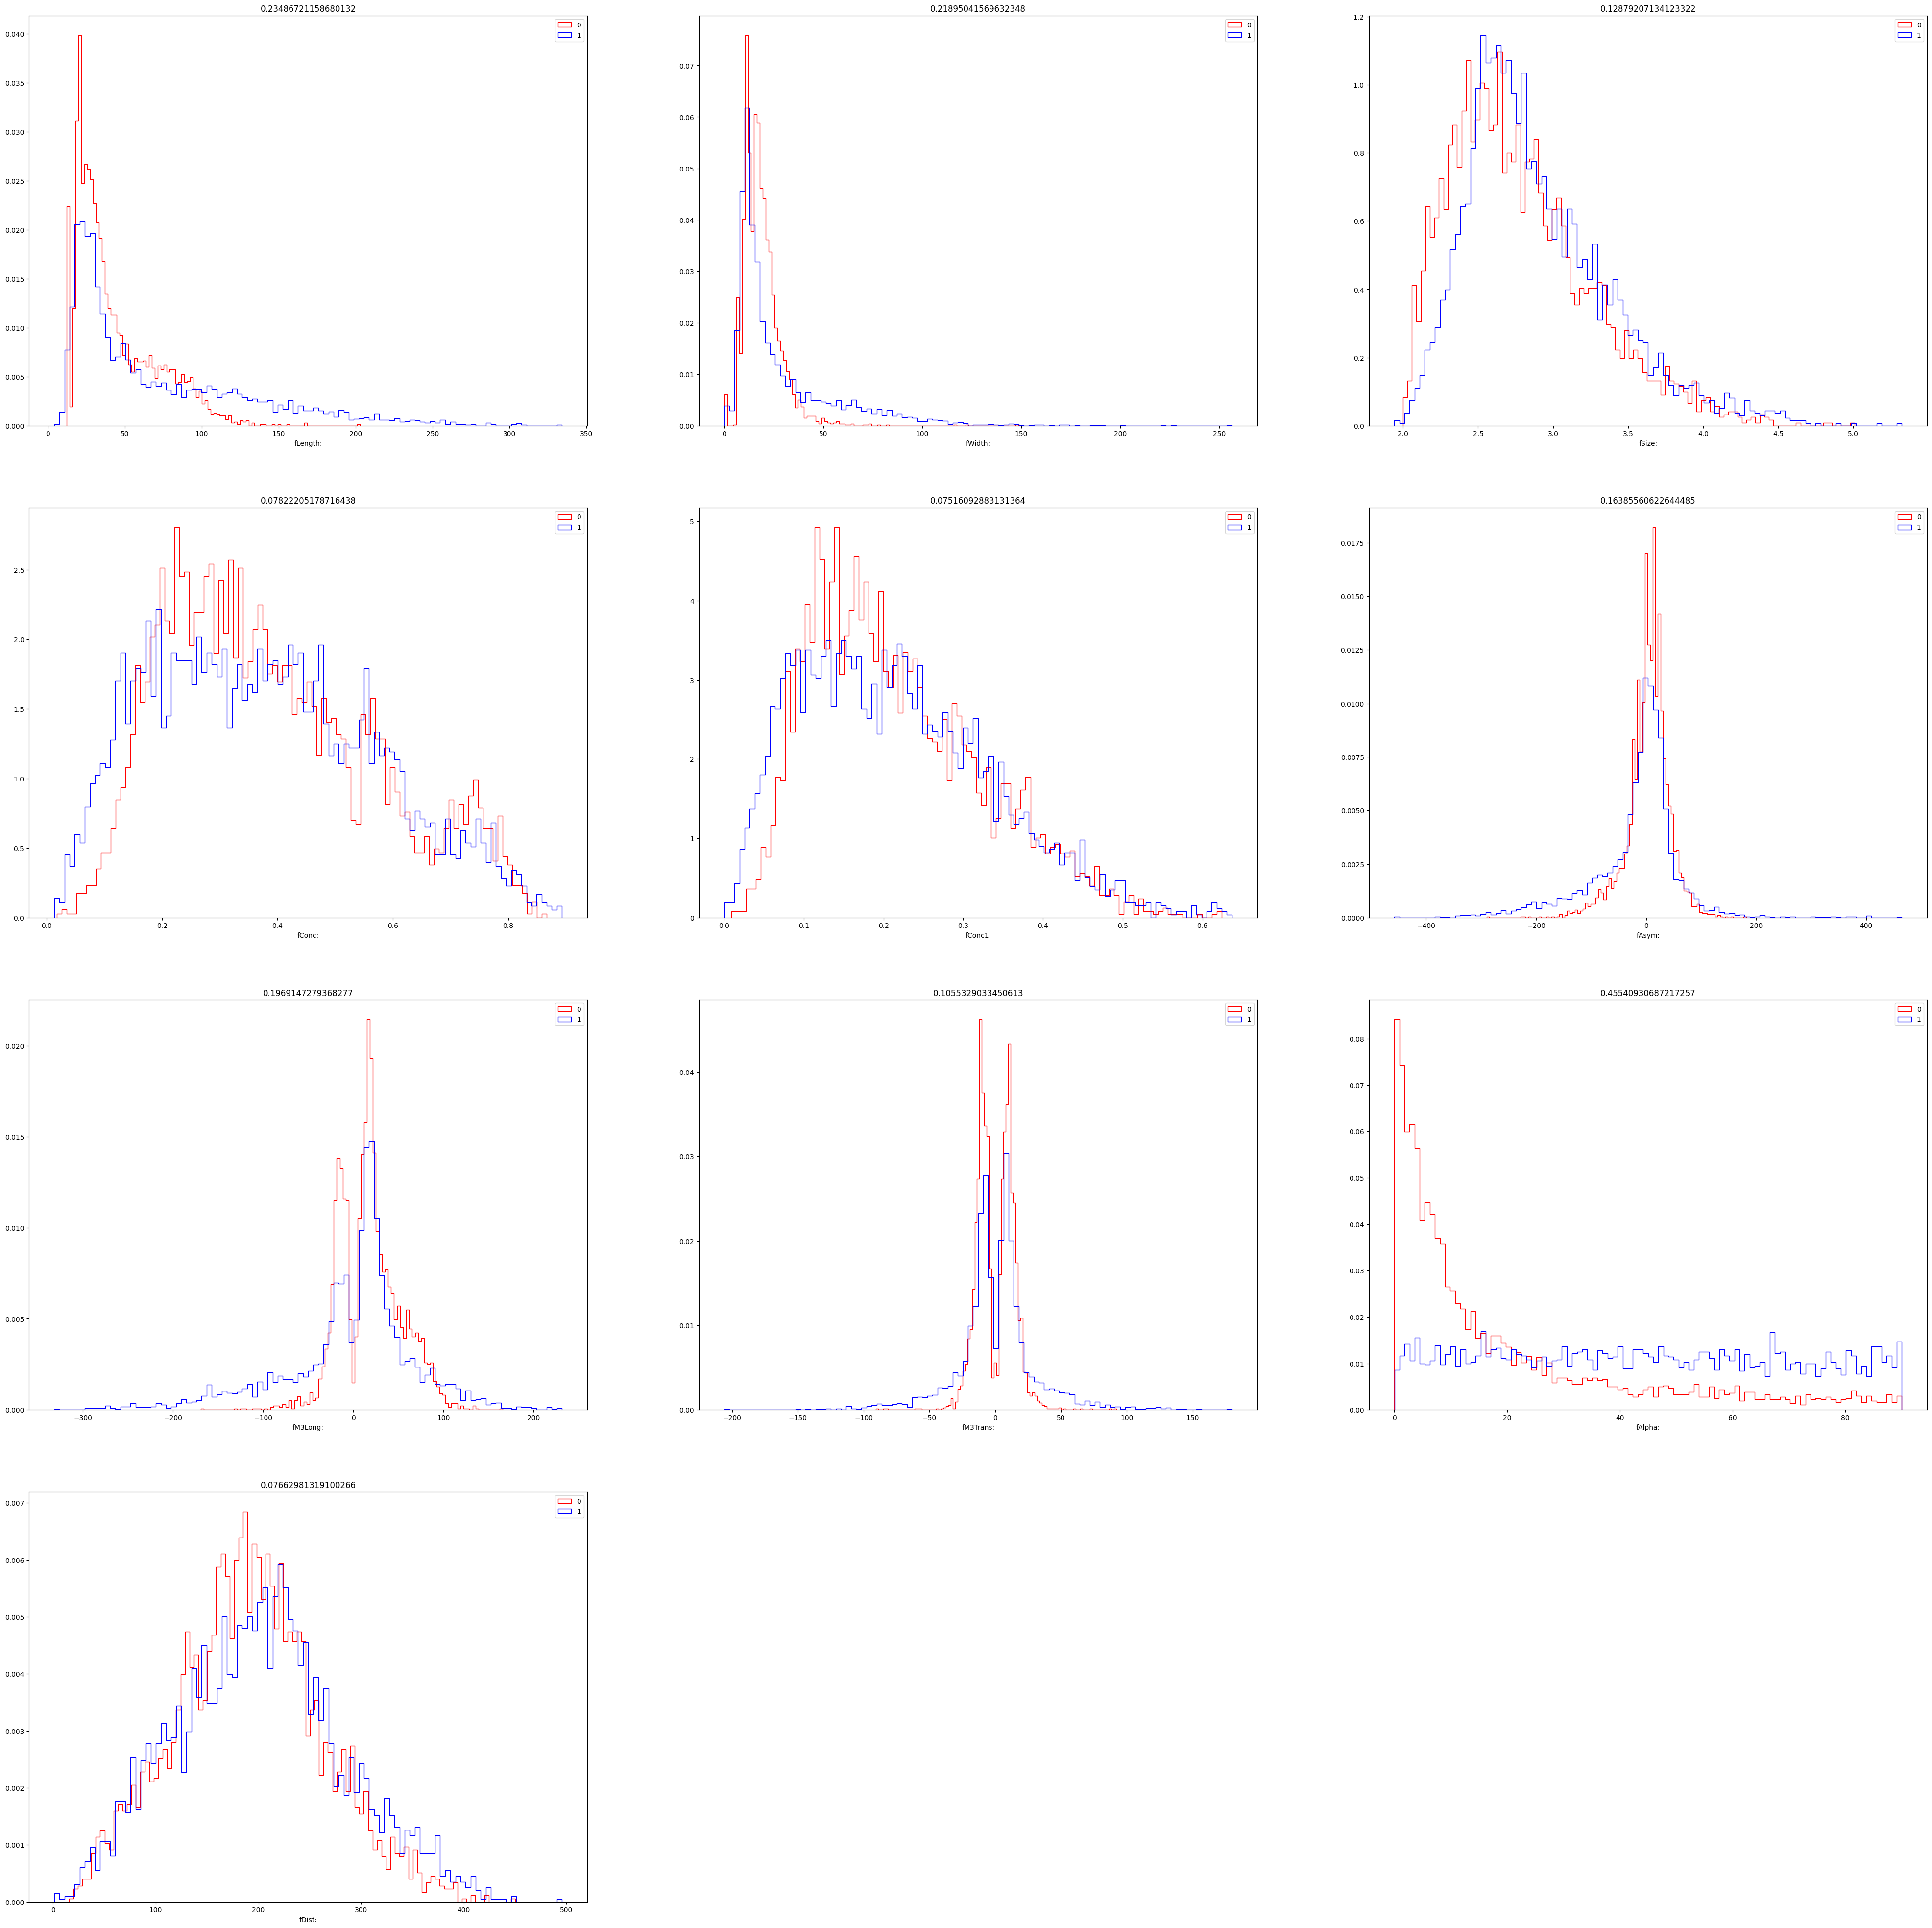

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
compare_features_binary(d1)

Quickly, we'll split our data into Training and Test subsets:

In [6]:
import math

N_total = d1["Training"].shape[0]
N_train = math.floor(.8*N_total)
N_val = math.floor((N_total-N_train)/2.)
N_test = math.floor((N_total-N_train)/2.)

X_Train = d1["Training"][:N_train]
y_Train = d1["Target"][:N_train]

X_val = d1["Training"][N_train:N_val+N_train]
y_val = d1["Target"][N_train:N_val+N_train]
                     
X_Test = d1["Training"][N_train+N_val:N_test+N_val+N_train]
y_Test = d1["Target"][N_train+N_val:N_test+N_val+N_train]

N_val

802

In [7]:
N_train

6420

## Building our first model

Here's our first model:

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(12, input_dim=X_Train.shape[1], activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Here we are specifying a few of the hyperparameters:

* The network architecture: we have 3 hidden layers, with 12, 8, and 8 neurons in each, respectively.
* We selected ReLU for the activations in the hidden layers.
* Because we are doing binary classifications, we selected sigmoid as the output activation.

Recall that the output activation corresponds to your task:
* Binary Classification: sigmoid
* Multi-class classification: softmax
* Regression: linear

Now let's quickly make sure we understand the number of parameters in our model. The number of input features:

In [10]:
X_Train.shape[1]

10

Lets quickly compute the number of parameters we expect in our model, layer by layer:

In [11]:
# 1st Hidde layer
X_Train.shape[1]*12 + 12

132

In [12]:
# 2nd Hidden layer
12 * 8 + 8

104

In [13]:
# 3rd Hidden layer
8 * 8 + 8

72

You can have Keras print out the model for you to investigate:

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 317 (1.24 KB)

 Trainable params: 317 (1.24 KB)

 Non-trainable params: 0 (0.00 B)

The preferred method of creating a model is to use functional API, where the Deep Neural Network is viewed as a composition of functions. With this API, you can create very sophisticated models with multiple inputs and outputs.

In [15]:
from keras.models import Model
from keras.layers import Dense, Input

in_x = Input(shape = X_Train.shape[1:])
x = Dense(12, input_dim=X_Train.shape[1], activation='relu')(in_x)
x = Dense(8, activation='relu')(x)
x = Dense(8, activation='relu')(x)
out_x = Dense(1, activation='sigmoid')(x)

model = Model(in_x,out_x)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 12)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 317 (1.24 KB)

 Trainable params: 317 (1.24 KB)

 Non-trainable params: 0 (0.00 B)

Few things to notice:
* Activations can be specified here, but can be added as their own layers.
* Note that in most cases where you are using existing Keras components with their default configuration, you can just specify the object you want by name. If you want to change a default, you'll have to create an instance of the object.

Since we haven't done any data normalization, we'll also add a layer to the model that does the normalization:

In [16]:
from keras.activations import relu
import keras

in_x = Input(shape = X_Train.shape[1:])
x = keras.layers.Normalization(axis=-1)(in_x)
x = Dense(12, input_dim=X_Train.shape[1], activation='relu')(in_x)
x = Dense(8)(x)
x = relu(x)
out_x = Dense(1, activation='sigmoid')(x)

model = Model(in_x,out_x)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 12)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 245 (980.00 B)

 Trainable params: 245 (980.00 B)

 Non-trainable params: 0 (0.00 B)

Once the DNN has been specified, we will have to further forumlate our problem by specifing the loss (the parameter which will be optimized during training), and the optimizer (the optimization algorithm). In Keras, these are specified at "compile" time:

In [17]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

Quick guide for selecting loss function:

* Binary Classification: binary_crossentropy
* Multi-class classification: categorical_crossentropy
* Regression: MSE

Note that we also specified a metric which Keras will compute for us during training so we can keep track of the progress of training. 

Few things to define and be aware of before we train:

* An epoch is defined as one training pass using the whole training data.
* Epochs are broken into smaller steps. At each step a subset of the training data, referred to as a batch, is used to compute the gradients perform an optimization step. Taking many steps is an example of stochastic gradient decent, which is an important ingredient to getting Deep Learning working.
* In order to monitor the training process, we typically compare the performance on the training sample and another sample (validation sample in Keras).

The easiest way to train is to use the `fit` method:

In [18]:
history=model.fit(X_Train.to_numpy().astype("float"), 
                  y_Train.to_numpy().astype("float"), 
                  validation_data=(X_Test.to_numpy(),y_Test.to_numpy()), 
                  epochs=100, batch_size=10)

Epoch 1/100
642/642 ━━━━━━━━━━━━━━━━━━━━ 1s 532us/step - accuracy: 0.5548 - loss: 3.1597 - val_accuracy: 0.6833 - val_loss: 0.6677
Epoch 2/100
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 392us/step - accuracy: 0.6315 - loss: 0.6433 - val_accuracy: 0.7157 - val_loss: 0.6276
Epoch 3/100
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 392us/step - accuracy: 0.7073 - loss: 0.5968 - val_accuracy: 0.7544 - val_loss: 0.5692
Epoch 4/100
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 391us/step - accuracy: 0.7517 - loss: 0.5491 - val_accuracy: 0.7569 - val_loss: 0.5430
Epoch 5/100
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 387us/step - accuracy: 0.7589 - loss: 0.5266 - val_accuracy: 0.7668 - val_loss: 0.5163
Epoch 6/100
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step - accuracy: 0.7625 - loss: 0.5086 - val_accuracy: 0.7693 - val_loss: 0.4952
Epoch 7/100
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 393us/step - accuracy: 0.7618 - loss: 0.4908 - val_accuracy: 0.7631 - val_loss: 0.4891
Epoch 8/100
642/642 ━━━━━━━━━━━━━━━━━━━━ 0s 398us/step - accuracy: 0.7662 - loss: 0

Note that `fit` takes care of

* Running multiple epochs
* Dividing the data into batches
* Computing gradient on each batch
* Using optimizer to take step
* Evaluating performance on training and testing data
* Keep track of everything

But in some instances you may wish to consume data from a difference source (rather than a tensor in memory) or do something different (e.g. training an Adversarial network), which will require you to perform some of these steps yourself. Keras provides easy methods to enable such functionality.

The model history keeps track of the loss and accuracy for each epoch. Note that the training above was setup to run on the validation sample at the end of each epoch:

In [19]:
print (history.history)

{'accuracy': [0.5548286437988281, 0.6314641833305359, 0.7073208689689636, 0.7517133951187134, 0.7588785290718079, 0.7624610662460327, 0.7618380188941956, 0.7661993503570557, 0.7686915993690491, 0.772429883480072, 0.7783489227294922, 0.7766355276107788, 0.781931459903717, 0.7792834639549255, 0.7839564085006714, 0.7789719700813293, 0.7853582501411438, 0.7884735465049744, 0.7844236493110657, 0.7848909497261047, 0.7897196412086487, 0.7886292934417725, 0.7925233840942383, 0.7919003367424011, 0.7922118306159973, 0.7920560836791992, 0.7926791310310364, 0.7908099889755249, 0.795171320438385, 0.7939252257347107, 0.7978193163871765, 0.7957943677902222, 0.7950155735015869, 0.7973520159721375, 0.7961059212684631, 0.7968847155570984, 0.7976635694503784, 0.7967289686203003, 0.7961059212684631, 0.7981308698654175, 0.8017134070396423, 0.7945482730865479, 0.8014018535614014, 0.7981308698654175, 0.7989096641540527, 0.7979750633239746, 0.7973520159721375, 0.8031152486801147, 0.7984423637390137, 0.8004673

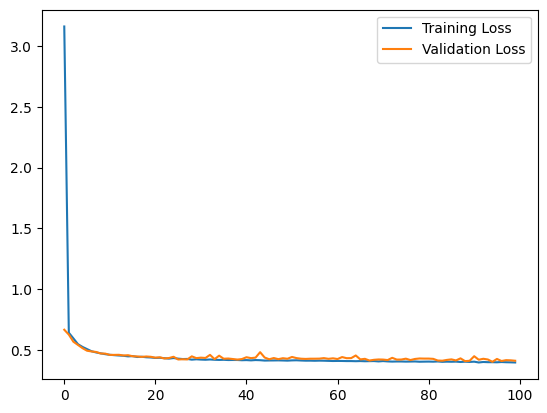

In [20]:
plt.plot(range(len(history.history["loss"])),history.history["loss"],label="Training Loss")
plt.plot(range(len(history.history["val_loss"])),history.history["val_loss"],label="Validation Loss")
plt.legend()

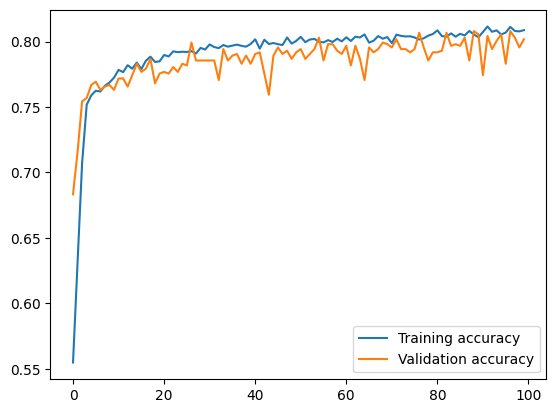

In [21]:
plt.plot(range(len(history.history["accuracy"])),history.history["accuracy"],label="Training accuracy")
plt.plot(range(len(history.history["val_accuracy"])),history.history["val_accuracy"],label="Validation accuracy")
plt.legend()

We can evaluate how the trained model does on the test sample as follows:

In [22]:
scores = model.evaluate(X_Test, y_Test)
print(scores)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - accuracy: 0.8017 - loss: 0.4128
[0.4128482937812805, 0.8017456531524658]


While evaluate is useful for assessing performance, once you have trained a model and determined you with to use it, you will want to apply to data without ground truth or the known desired output (in this case signal or background). `predict` enables this functionality:

In [23]:
model.predict(X_Test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step


array([[0.96880186],
       [0.34719864],
       [0.0385419 ],
       [0.9996557 ],
       [0.5819161 ],
       [0.30763078],
       [0.14460692],
       [0.99502254],
       [0.35882133],
       [0.8118792 ],
       [0.38326037],
       [0.36016324],
       [0.19195338],
       [0.6459974 ],
       [0.21254253],
       [0.3217792 ],
       [0.9999312 ],
       [0.9931891 ],
       [0.993055  ],
       [0.5978946 ],
       [0.0882866 ],
       [0.17683688],
       [0.18865576],
       [0.99854743],
       [0.10606682],
       [0.8771783 ],
       [0.01853527],
       [0.23094885],
       [0.6754368 ],
       [0.9999977 ],
       [0.43670157],
       [0.14757915],
       [0.05350453],
       [0.24843529],
       [0.8066707 ],
       [0.1392661 ],
       [0.05348881],
       [0.16791424],
       [0.43179628],
       [0.9358884 ],
       [0.53264916],
       [0.9916544 ],
       [0.03719727],
       [0.48676288],
       [0.5301853 ],
       [0.32608375],
       [0.53349054],
       [0.233

Note the output here is a number between 0 and 1. Determining what threshold to use to select signal is analgous to what we did for other ML methods.

Lets first look at the distribution of the output of the DNN to confirm visually that things are as we expect:

In [24]:
X_Test_0 = X_Test[(y_Test==0).to_numpy()]
X_Test_1 = X_Test[(y_Test==1).to_numpy()]

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step


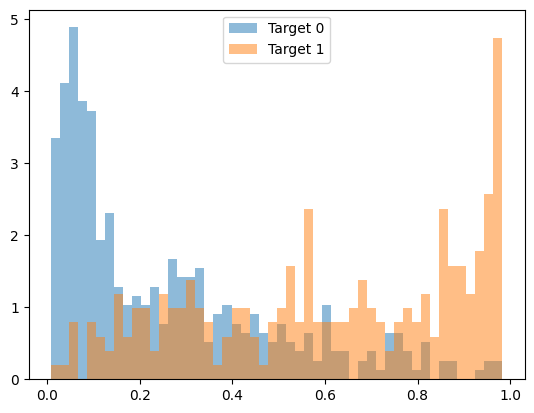

In [25]:
hist,bins,_= plt.hist(model.predict(X_Test_0),density=1,bins=50,alpha=0.5,label="Target 0")
hist,bins,_= plt.hist(model.predict(X_Test_1),density=1,bins=bins,alpha=0.5,label="Target 1")
plt.legend()

Next, we make ROC curves:

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step


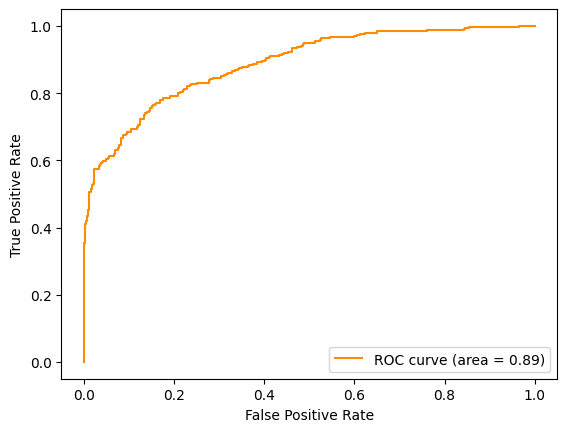

In [26]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, model.predict(X_Test))
                        
roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()